# Libraries

In [ ]:
import datasets
from pyspark.sql import SparkSession, DataFrame
from pyspark.sql.functions import col, rtrim, pandas_udf, explode, lit
from functools import reduce
import tiktoken
import pandas as pd
import plotly.express as px
import numpy as np
from langchain_text_splitters import RecursiveCharacterTextSplitter
from pyspark.sql.types import ArrayType, StringType
from dotenv import load_dotenv
import os
from openai import OpenAI
import json
import plotly.graph_objects as go
import plotly.io as pio
from bs4 import BeautifulSoup
from pyspark.sql.functions import rand
import subprocess

load_dotenv()
API_KEY = os.getenv("OPENAI_API_KEY")

pio.renderers.default = "png"

client = OpenAI()
embedding_model ="text-embedding-3-small"
encoding = tiktoken.encoding_for_model(embedding_model)

/Users/ozyurtf/Documents/projects/aig-interview-furkan-ozyurt/aig/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Spark Session Initialization

In [2]:
spark = SparkSession.builder\
    .master('local[*]')\
    .appName('AIG_RAG')\
    .config('spark.driver.memory', '8g')\
    .config('spark.sql.execution.arrow.pyspark.enabled', 'true')\
    .config('spark.sql.shuffle.partitions', '8')\
    .getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/20 12:55:35 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


# Functions

In [3]:
@pandas_udf("int")
def count_tokens(series: pd.Series) -> pd.Series:
    return series.apply(lambda x: len(encoding.encode(x)))

@pandas_udf(ArrayType(StringType()))
def split_chunks(text: pd.Series) -> pd.Series:
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=2000, 
        chunk_overlap=100
    )
    chunks = text.apply(lambda t: text_splitter.split_text(t) if t else [])
    return chunks

@pandas_udf("boolean")
def contains_html(series: pd.Series) -> pd.Series:
    def has_html(text: str) -> bool:
        return bool(BeautifulSoup(text, "html.parser").find())
    return series.apply(has_html)

# Saving Raw Dataset as Parquet

In [4]:
raw_dataset = datasets.load_dataset("eloukas/edgar-corpus", "full")

Using the latest cached version of the dataset since eloukas/edgar-corpus couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'full' at /Users/ozyurtf/.cache/huggingface/datasets/eloukas___edgar-corpus/full/1.0.0/c2f9ada1db31915d6af4cc19f0ad9486cd0bab93c5c26bb32850e5a1f74f2bd7 (last modified on Wed Apr 15 13:36:41 2026).


In [5]:
raw_dataset

DatasetDict({
    train: Dataset({
        features: ['filename', 'cik', 'year', 'section_1', 'section_1A', 'section_1B', 'section_2', 'section_3', 'section_4', 'section_5', 'section_6', 'section_7', 'section_7A', 'section_8', 'section_9', 'section_9A', 'section_9B', 'section_10', 'section_11', 'section_12', 'section_13', 'section_14', 'section_15'],
        num_rows: 176289
    })
    validation: Dataset({
        features: ['filename', 'cik', 'year', 'section_1', 'section_1A', 'section_1B', 'section_2', 'section_3', 'section_4', 'section_5', 'section_6', 'section_7', 'section_7A', 'section_8', 'section_9', 'section_9A', 'section_9B', 'section_10', 'section_11', 'section_12', 'section_13', 'section_14', 'section_15'],
        num_rows: 22050
    })
    test: Dataset({
        features: ['filename', 'cik', 'year', 'section_1', 'section_1A', 'section_1B', 'section_2', 'section_3', 'section_4', 'section_5', 'section_6', 'section_7', 'section_7A', 'section_8', 'section_9', 'section_9A', '

In [6]:
# raw_dataset["train"].to_parquet("./parquet/edgar-train.parquet")
# raw_dataset["validation"].to_parquet("./parquet/edgar-validation.parquet")
# raw_dataset["test"].to_parquet("./parquet/edgar-test.parquet")

# Data Processing/Cleaning

In [7]:
sdf_train = spark.read.format("parquet").load('./parquet/edgar-train.parquet').withColumn("split", lit("train"))
sdf_validation = spark.read.format("parquet").load('./parquet/edgar-validation.parquet').withColumn("split", lit("validation"))
sdf_test = spark.read.format("parquet").load('./parquet/edgar-test.parquet').withColumn("split", lit("test"))

In [8]:
sdf_train.select("cik", "year", "section_1", "section_1A", "section_2").show(2, truncate=25)

+------+----+-------------------------+----------+-------------------------+
|   cik|year|                section_1|section_1A|                section_2|
+------+----+-------------------------+----------+-------------------------+
| 92116|1993|Item 1. Business\nGene...|          |Item 2 - Properties\nF...|
|103730|1993|Item 1. DESCRIPTION OF...|          |Item 2. PROPERTIES - -...|
+------+----+-------------------------+----------+-------------------------+
only showing top 2 rows


In [9]:
sdf = reduce(DataFrame.unionByName, [sdf_train, sdf_validation, sdf_test])

In [10]:
sdf

DataFrame[filename: string, cik: string, year: string, section_1: string, section_1A: string, section_1B: string, section_2: string, section_3: string, section_4: string, section_5: string, section_6: string, section_7: string, section_7A: string, section_8: string, section_9: string, section_9A: string, section_9B: string, section_10: string, section_11: string, section_12: string, section_13: string, section_14: string, section_15: string, split: string]

In [11]:
sdf.filter(col("cik").startswith("0")).count()

0

In [12]:
count_5272 = sdf.filter((col("cik") == '5272')).count()
count_1000617 = sdf.filter((col("cik") == '1000617')).count()
count_1503633 = sdf.filter((col("cik") == '1503633')).count()

print(f"Entire dataset has: \n - {count_5272} records with CIK = 5272 \n - {count_1000617} records with CIK = 1000617 \n - {count_1503633} records with CIK = 1503633")

Entire dataset has: 
 - 28 records with CIK = 5272 
 - 0 records with CIK = 1000617 
 - 0 records with CIK = 1503633


In [13]:
sdf_aig = sdf.filter(col("cik") == 5272).drop("split", "filename").melt(
    ids = ["cik", "year"], 
    values =  ['section_1', 'section_1A', 'section_1B',
               'section_2', 'section_3', 'section_4',
               'section_5', 'section_6', 'section_7',
               'section_7A', 'section_8', 'section_9',
               'section_9A', 'section_9B', 'section_10',
               'section_11', 'section_12', 'section_13',
               'section_14', 'section_15'],
    variableColumnName = "section",
    valueColumnName = "description"
)

In [14]:
sdf_aig.show()

+----+----+----------+--------------------+
| cik|year|   section|         description|
+----+----+----------+--------------------+
|5272|1994| section_1|ITEM 1. BUSINESS\...|
|5272|1994|section_1A|                    |
|5272|1994|section_1B|                    |
|5272|1994| section_2|ITEM 2. PROPERTIE...|
|5272|1994| section_3|ITEM 3. LEGAL PRO...|
|5272|1994| section_4|ITEM 4. SUBMISSIO...|
|5272|1994| section_5|ITEM 5. MARKET FO...|
|5272|1994| section_6|ITEM 6. SELECTED ...|
|5272|1994| section_7|ITEM 7. MANAGEMEN...|
|5272|1994|section_7A|                    |
|5272|1994| section_8|ITEM 8. FINANCIAL...|
|5272|1994| section_9|ITEM 9. CHANGES I...|
|5272|1994|section_9A|                    |
|5272|1994|section_9B|                    |
|5272|1994|section_10|ITEM 10. DIRECTOR...|
|5272|1994|section_11|ITEM 11. EXECUTIV...|
|5272|1994|section_12|ITEM 12. SECURITY...|
|5272|1994|section_13|ITEM 13. CERTAIN ...|
|5272|1994|section_14|ITEM 14. EXHIBITS...|
|5272|1994|section_15|          

In [15]:
sdf_aig \
    .withColumn("contain_html", contains_html(col("description"))) \
    .filter(col("contain_html") == True) \
    .count()

0

In [16]:
sdf_aig = sdf_aig.withColumn("description", rtrim(col("description")))

In [17]:
null_counts = {c: sdf_aig.filter(col(c).isNull()).count() for c in sdf_aig.columns} 
print(null_counts)

{'cik': 0, 'year': 0, 'section': 0, 'description': 0}


In [18]:
empty_counts = sdf_aig.where(col("description") == "").count()
print(empty_counts)

86


In [19]:
sdf_aig = sdf_aig.na.drop(subset=['description']).filter(col('description') != "")

In [20]:
sdf_aig.cache()

DataFrame[cik: string, year: string, section: string, description: string]

In [21]:
sdf_aig.show(10)

+----+----+----------+--------------------+
| cik|year|   section|         description|
+----+----+----------+--------------------+
|5272|1994| section_1|ITEM 1. BUSINESS\...|
|5272|1994| section_2|ITEM 2. PROPERTIE...|
|5272|1994| section_3|ITEM 3. LEGAL PRO...|
|5272|1994| section_4|ITEM 4. SUBMISSIO...|
|5272|1994| section_5|ITEM 5. MARKET FO...|
|5272|1994| section_6|ITEM 6. SELECTED ...|
|5272|1994| section_7|ITEM 7. MANAGEMEN...|
|5272|1994| section_8|ITEM 8. FINANCIAL...|
|5272|1994| section_9|ITEM 9. CHANGES I...|
|5272|1994|section_10|ITEM 10. DIRECTOR...|
+----+----+----------+--------------------+
only showing top 10 rows


In [22]:
sdf_aig.count()

474

# Chunking

In [23]:
sdf_aig.select(
    col("year"),
    col("section"),
    col("description"),
    count_tokens(col("description")).alias("token_count")
).show()

+----+----------+--------------------+-----------+
|year|   section|         description|token_count|
+----+----------+--------------------+-----------+
|1994| section_1|ITEM 1. BUSINESS\...|       6102|
|1994| section_2|ITEM 2. PROPERTIE...|        158|
|1994| section_3|ITEM 3. LEGAL PRO...|        104|
|1994| section_4|ITEM 4. SUBMISSIO...|        399|
|1994| section_5|ITEM 5. MARKET FO...|        407|
|1994| section_6|ITEM 6. SELECTED ...|        222|
|1994| section_7|ITEM 7. MANAGEMEN...|      16964|
|1994| section_8|ITEM 8. FINANCIAL...|      19790|
|1994| section_9|ITEM 9. CHANGES I...|         64|
|1994|section_10|ITEM 10. DIRECTOR...|         89|
|1994|section_11|ITEM 11. EXECUTIV...|         59|
|1994|section_12|ITEM 12. SECURITY...|         67|
|1994|section_13|ITEM 13. CERTAIN ...|         67|
|1994|section_14|ITEM 14. EXHIBITS...|       1093|
|1995| section_1|ITEM 1. BUSINESS\...|       6107|
|1995| section_2|ITEM 2. PROPERTIE...|        158|
|1995| section_3|ITEM 3. LEGAL 

In [24]:
pdf = sdf_aig.select(
    count_tokens(col("description")).alias("token_count")
).toPandas()

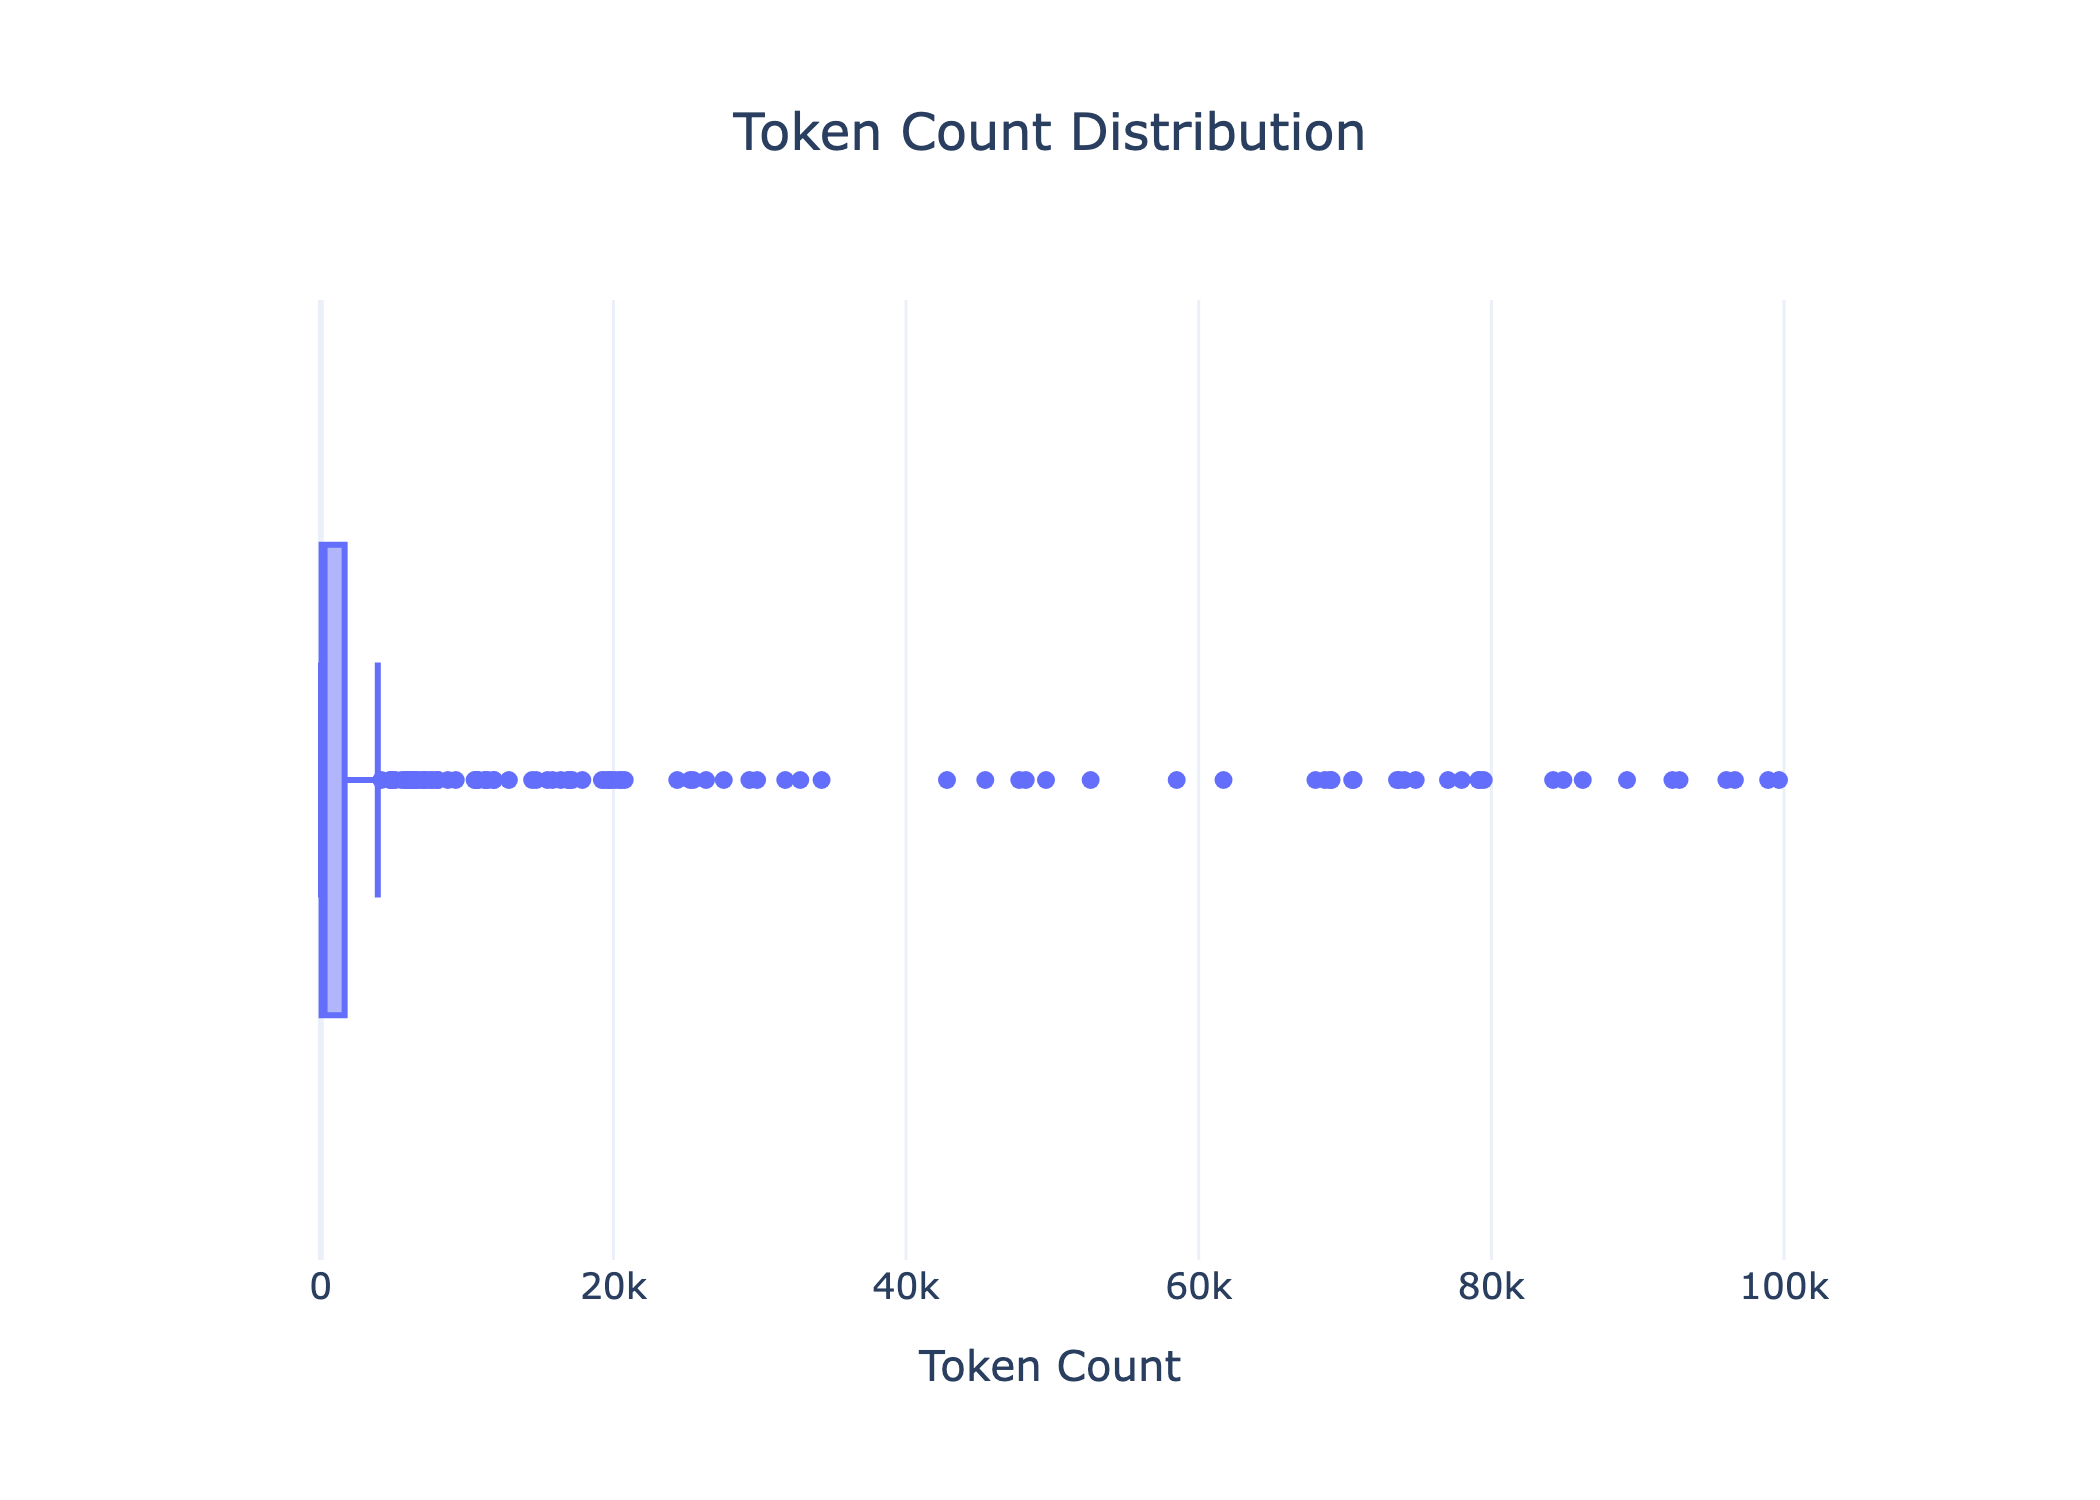

In [25]:
fig = px.box(
    pdf,
    x="token_count",  
    points="outliers",
    title="Token Count Distribution"
)

fig.update_layout(
    xaxis_title="Token Count",
    title_x=0.5,
    template="plotly_white"
)

fig.show(scale=3)

In [26]:
q = 70
avg_chunk_size = 500

q_token_count = int(pdf["token_count"].quantile(q / 100))
total_tokens = pdf["token_count"].sum()
num_chunks = total_tokens // avg_chunk_size

print(f"{q}% of the sections has less than or equal to ~{q_token_count} number of tokens.")
print(f"Total number of tokens across all the sections is: {total_tokens}.")
print(f"This means that if we want the average chunk size to be ~{avg_chunk_size}, for instance, we will have ~{num_chunks} number of chunks.")

70% of the sections has less than or equal to ~966 number of tokens.
Total number of tokens across all the sections is: 3491821.
This means that if we want the average chunk size to be ~500, for instance, we will have ~6983 number of chunks.


In [27]:
sdf_aig_final = sdf_aig \
    .withColumn("chunks", split_chunks(col("description"))) \
    .withColumn("chunks", explode(col("chunks"))) \
    .drop("cik", "description")

In [28]:
sdf_aig_final.show()

+----+---------+--------------------+
|year|  section|              chunks|
+----+---------+--------------------+
|1994|section_1|ITEM 1. BUSINESS\...|
|1994|section_1|At December 31, 1...|
|1994|section_1|AIG's business de...|
|1994|section_1|American Internat...|
|1994|section_1|AIG's general ins...|
|1994|section_1|The following tab...|
|1994|section_1|Loss reserves est...|
|1994|section_1|had actually been...|
|1994|section_1|Approximately 50 ...|
|1994|section_1|LIFE INSURANCE OP...|
|1994|section_1|Traditional life ...|
|1994|section_1|(c) Includes $61,...|
|1994|section_1|AGENCY AND SERVIC...|
|1994|section_1|FINANCIAL SERVICE...|
|1994|section_1|* Represents net ...|
|1994|section_1|LOCATIONS OF CERT...|
|1994|section_1|AIG's insurance s...|
|1994|section_1|The RBC Model Law...|
|1994|section_1|In addition to li...|
|1994|section_2|ITEM 2. PROPERTIE...|
+----+---------+--------------------+
only showing top 20 rows


In [29]:
sdf_aig_final.count()

11162

In [30]:
sdf_aig_final.select(
    col("year"),
    col("section"),
    col("chunks"),
    count_tokens(col("chunks")).alias("token_count")
).show()

+----+---------+--------------------+-----------+
|year|  section|              chunks|token_count|
+----+---------+--------------------+-----------+
|1994|section_1|ITEM 1. BUSINESS\...|        329|
|1994|section_1|At December 31, 1...|        368|
|1994|section_1|AIG's business de...|        306|
|1994|section_1|American Internat...|        321|
|1994|section_1|AIG's general ins...|        325|
|1994|section_1|The following tab...|        336|
|1994|section_1|Loss reserves est...|        273|
|1994|section_1|had actually been...|        371|
|1994|section_1|Approximately 50 ...|        356|
|1994|section_1|LIFE INSURANCE OP...|        349|
|1994|section_1|Traditional life ...|        383|
|1994|section_1|(c) Includes $61,...|        314|
|1994|section_1|AGENCY AND SERVIC...|        217|
|1994|section_1|FINANCIAL SERVICE...|        345|
|1994|section_1|* Represents net ...|        377|
|1994|section_1|LOCATIONS OF CERT...|        320|
|1994|section_1|AIG's insurance s...|        330|


In [31]:
pdf_final = sdf_aig_final.select(
    count_tokens(col("chunks")).alias("token_count")
).toPandas()

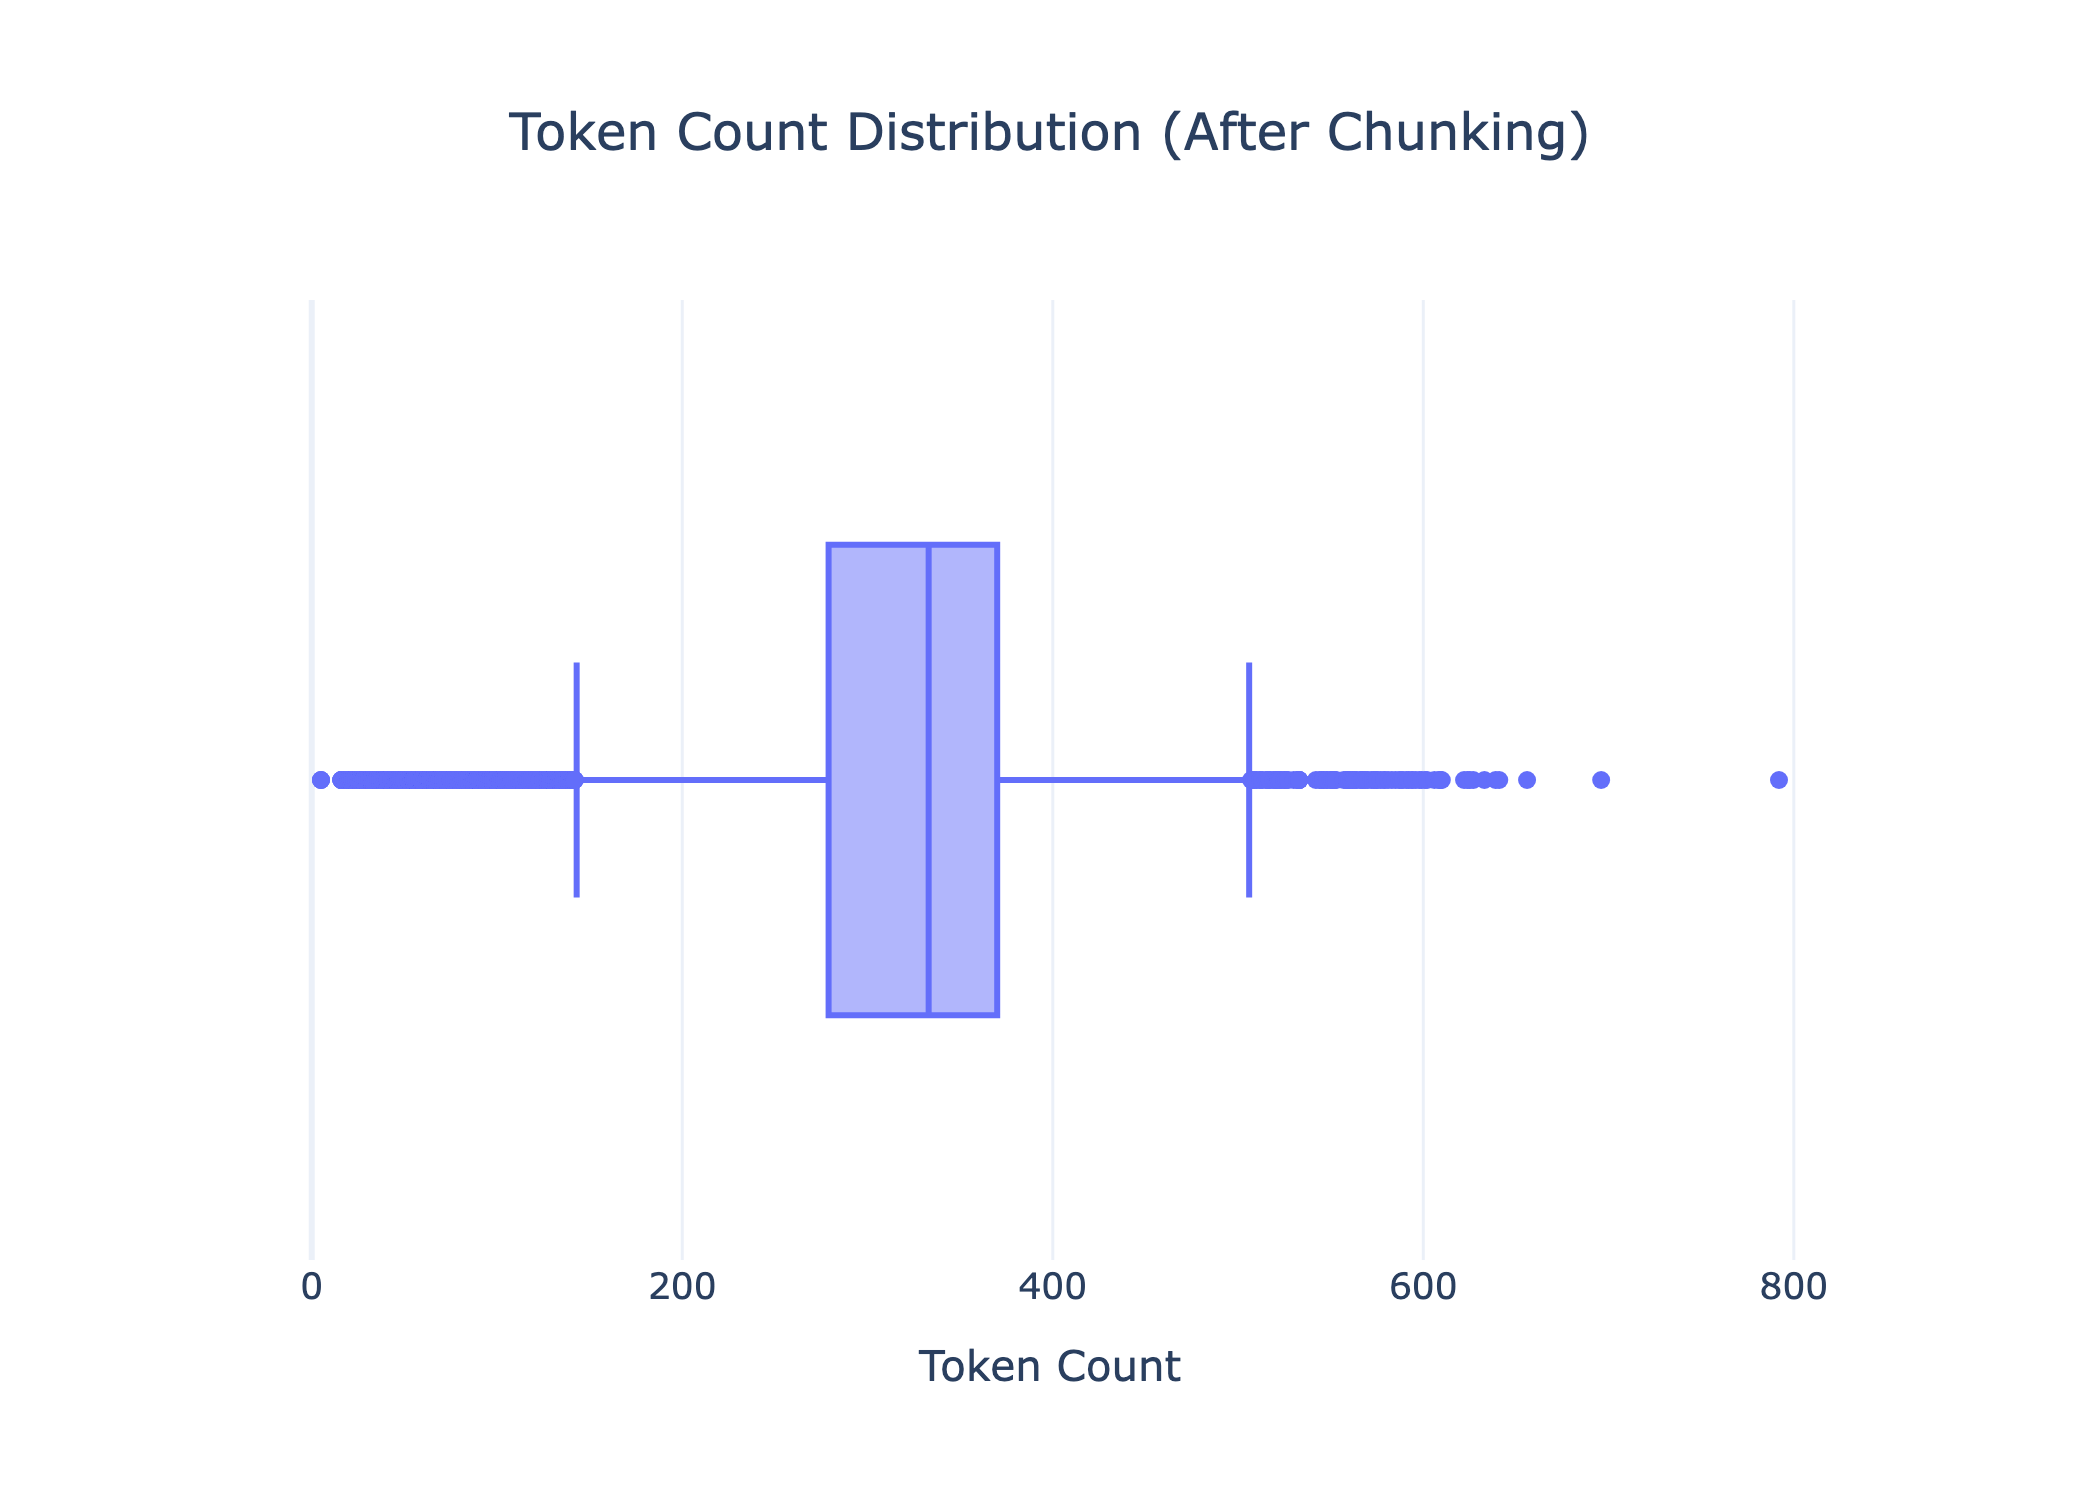

In [32]:
fig = px.box(
    pdf_final,
    x="token_count",  
    points="outliers",
    title="Token Count Distribution (After Chunking)"
)

fig.update_layout(
    xaxis_title="Token Count",
    title_x=0.5,
    template="plotly_white"
)

fig.show(scale=3)

In [33]:
max_token_count = max(pdf_final["token_count"])
min_token_count = min(pdf_final["token_count"])
avg_token_count = np.round(np.mean(pdf_final["token_count"]), 2)
median_token_count = np.median(pdf_final["token_count"])

print(f"After the chunking process: \n - The minimum number of tokens: {min_token_count} \n - The maximum number of tokens: {max_token_count} \n - Average number of tokens: {avg_token_count} \n - Median token number: {median_token_count}")

After the chunking process: 
 - The minimum number of tokens: 5 
 - The maximum number of tokens: 792 
 - Average number of tokens: 317.3 
 - Median token number: 333.0


# Indexing

In [34]:
spark.read.format("parquet").load("vector-database/config_text-embedding-3-small_2000_100/aig.parquet").orderBy(rand()).show()

+----+----------+--------------------+--------------------+
|year|   section|              chunks|           embedding|
+----+----------+--------------------+--------------------+
|2020|section_1A|AIG | 2020 Form 1...|[0.0146484375, 0....|
|2020| section_8|In connection wit...|[-0.0068969726562...|
|2009| section_8|(s) Commercial Pa...|[0.00881958007812...|
|2008|section_1A|Use of Estimates\...|[0.05340576171875...|
|2017| section_8|Restricted Cash\n...|[0.03488159179687...|
|2009| section_7|Noncore Businesse...|[0.03001403808593...|
|2013|section_1A|•significant inte...|[0.02572631835937...|
|2007| section_7|Besides model enh...|[0.00900268554687...|
|2009| section_8|In our opinion, t...|[0.0504150390625,...|
|2017| section_8|We also defer a p...|[0.01526641845703...|
|2012| section_8|Industry-wide exa...|[0.00725173950195...|
|2017| section_8|Affordable Housin...|[0.00193500518798...|
|2006| section_7|Net premiums writ...|[0.0372314453125,...|
|2010| section_7|•Taking underwrit...|[0

# RAG

In [35]:
query = "What proportion of AIG’s consolidated assets in 2012 was held outside the United States and Canada? Return the answer in the exact format: <number> percent"

query = "Tell me the cities and states of the offices owned by AIG and its subsidiaries in 2016 in the US."

cmd = [
    "python", "rag.py",
    "--query", "Tell me the cities and states of the offices owned by AIG and its subsidiaries in 2016 in the US.",
    "--alpha", "0.5",
    "--top-k", "10",
    "--temperature", "0.0",
    "--max-tokens", "500"
]

response = subprocess.run(cmd, capture_output=True, text=True).stdout
print(response)

[0.00s] Start
[1.74s] Years extracted: ['2016']
[3.13s] Query embedding and data loaded
[3.19s] Hybrid search finished
[3.19s] Context built
[5.88s] Final LLM response
As of 2016, AIG and its subsidiaries owned offices in the following cities and states in the United States:

1. Stevens Point, Wisconsin (Property Casualty Insurance Companies)
2. Amarillo, Texas (Life Insurance Companies)
3. Houston, Texas (Life Insurance Companies)
4. New York, New York (Other Operations - 175 Water Street)
5. Livingston, New Jersey (Other Operations)
6. Stowe, Vermont (Other Operations)
7. Ft. Worth, Texas (Other Operations)



# Ground Truth Data

### Numerical Variable - 1

In [36]:
description = sdf_aig.filter(
    (col("year") == 2012) & (col("section") == "section_2")
).select("description").collect()[0]["description"]

# print(description)

In [37]:
description = sdf_aig.filter(
    (col("year") == 2013) & (col("section") == "section_2")
).select("description").collect()[0]["description"]

# print(description)

In [38]:
description = sdf_aig.filter(
    (col("year") == 2014) & (col("section") == "section_2")
).select("description").collect()[0]["description"]

# print(description)

In [39]:
description = sdf_aig.filter(
    (col("year") == 2016) & (col("section") == "section_2")
).select("description").collect()[0]["description"]

# print(description)

In [40]:
description = sdf_aig.filter(
    (col("year") == 2017) & (col("section") == "section_2")
).select("description").collect()[0]["description"]

# print(description)

### Numerical Variable - 2

In [41]:
description = sdf_aig.filter(
    (col("year") == 2012) & (col("section") == "section_7")
).select("description").collect()[0]["description"]

# print(description)

In [42]:
description = sdf_aig.filter(
    (col("year") == 2015) & (col("section") == "section_7")
).select("description").collect()[0]["description"]

# print(description)

In [43]:
description = sdf_aig.filter(
    (col("year") == 2016) & (col("section") == "section_7")
).select("description").collect()[0]["description"]

# print(description)

In [44]:
description = sdf_aig.filter(
    (col("year") == 2017) & (col("section") == "section_7")
).select("description").collect()[0]["description"]

# print(description)

In [45]:
description = sdf_aig.filter(
    (col("year") == 2018) & (col("section") == "section_7")
).select("description").collect()[0]["description"]

# print(description)

### Categorical Variable - 1

In [46]:
description = sdf_aig.filter(
    (col("year") == 1995) & (col("section") == "section_2")
).select("description").collect()[0]["description"]

# print(description)

In [47]:
description = sdf_aig.filter(
    (col("year") == 1999) & (col("section") == "section_2")
).select("description").collect()[0]["description"]

# print(description)

In [48]:
description = sdf_aig.filter(
    (col("year") == 2004) & (col("section") == "section_2")
).select("description").collect()[0]["description"]

# print(description)

In [49]:
description = sdf_aig.filter(
    (col("year") == 2010) & (col("section") == "section_2")
).select("description").collect()[0]["description"]

# print(description)

In [50]:
description = sdf_aig.filter(
    (col("year") == 2016) & (col("section") == "section_2")
).select("description").collect()[0]["description"]

# print(description)

# Evaluation

In [51]:
path1 = "eval/config_alpha-0.0_topk-10_temperature-0.0"
path2 = "eval/config_alpha-0.5_topk-10_temperature-0.0"
path3 = "eval/config_alpha-1.0_topk-10_temperature-0.0"

with open(path1 + "/scores.json", "r") as f:
    scores1 = json.load(f)

with open(path2 + "/scores.json", "r") as f:
    scores2 = json.load(f)    

with open(path3 + "/scores.json", "r") as f:
    scores3 = json.load(f)        

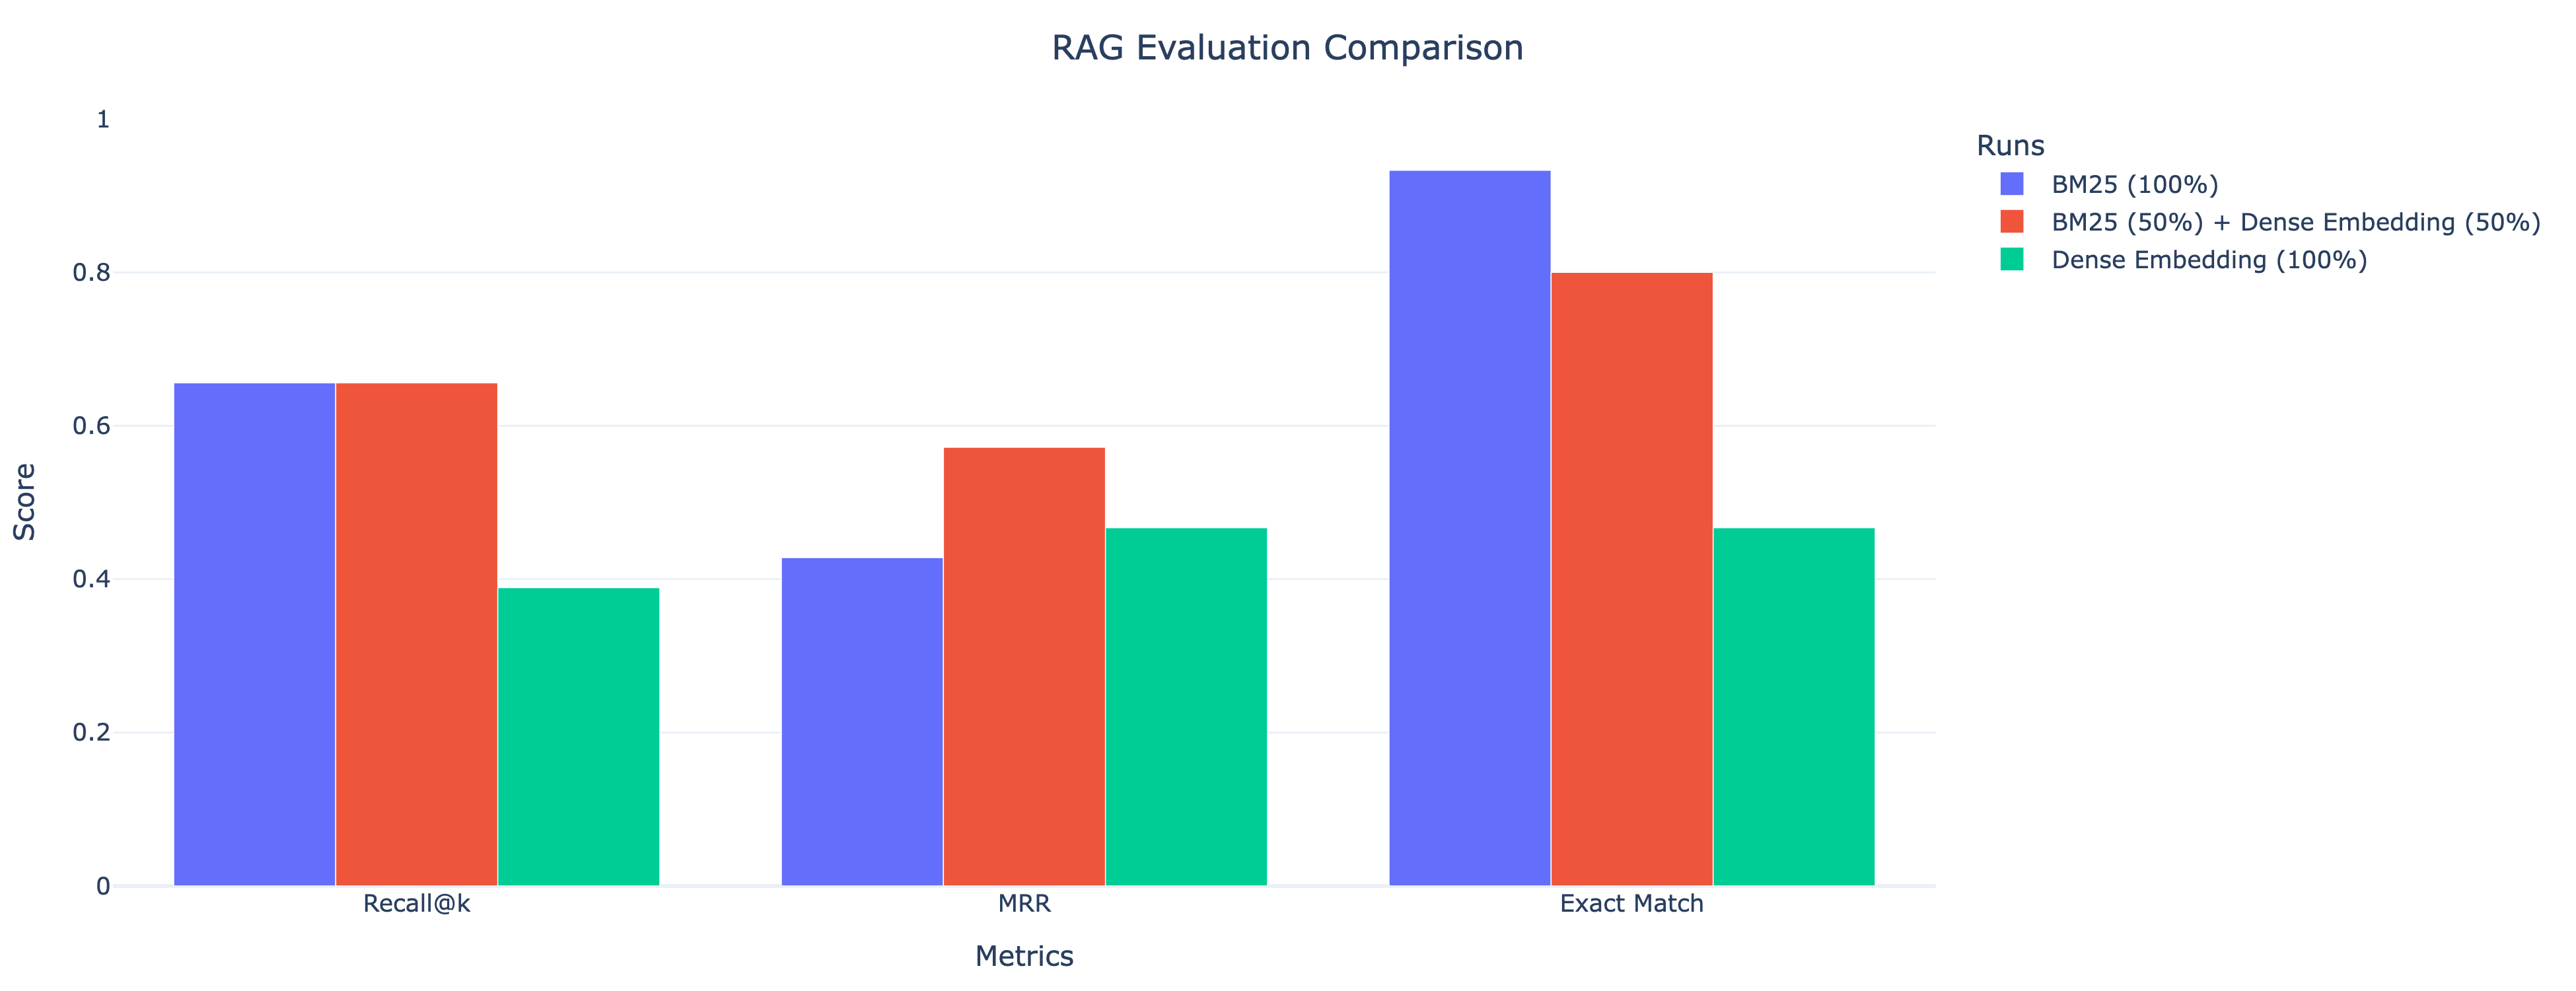

In [52]:
metric_labels = {
    "recall_k": "Recall@k",
    "mrr": "MRR",
    "exact_match_score": "Exact Match"
}

metrics = list(metric_labels.keys())
pretty_names = [metric_labels[m] for m in metrics]

def extract_scores(scores):
    return {
        "recall_k": scores["retriever"]["recall_k"],
        "mrr": scores["retriever"]["mrr"],
        "exact_match_score": scores["generator"]["exact_match_score"],
    }

s1 = extract_scores(scores1)
s2 = extract_scores(scores2)
s3 = extract_scores(scores3)

fig = go.Figure()

fig.add_trace(go.Bar(
    name="BM25 (100%)",
    x=pretty_names,
    y=[s1[m] for m in metrics],
))

fig.add_trace(go.Bar(
    name="BM25 (50%) + Dense Embedding (50%)",
    x=pretty_names,
    y=[s2[m] for m in metrics],
))

fig.add_trace(go.Bar(
    name="Dense Embedding (100%)",
    x=pretty_names,
    y=[s3[m] for m in metrics],
))

fig.update_layout(
    title="RAG Evaluation Comparison",
    title_x=0.5,
    barmode="group",
    xaxis_title="Metrics",
    yaxis_title="Score",
    yaxis=dict(range=[0, 1]),
    template="plotly_white",
    width=1300,
    height=500,
    margin=dict(l=40, r=40, t=60, b=40),
    legend_title="Runs"
)

fig.show(scale=3) 